### Plantix - Plant Disease Prediction

In [58]:
# Importing libraries
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, Rescaling, RandomFlip, RandomRotation, RandomZoom, RandomContrast #type: ignore
from tensorflow.keras.models import Sequential #type: ignore
from tensorflow.keras.regularizers import l2 #type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau #type: ignore
import json

##### Data Preprocessing

In [24]:
training_set = tf.keras.utils.image_dataset_from_directory(
    "C:/Users/Aadarsh/Desktop/Plantix/data/train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 70295 files belonging to 38 classes.


In [25]:
# Validation image preprocessing
validation_set = tf.keras.utils.image_dataset_from_directory(
    "C:/Users/Aadarsh/Desktop/Plantix/data/valid",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [26]:
training_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [27]:
validation_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [28]:
for x, y in training_set:
    print(x.shape)
    print(y.shape)
    break

(32, 128, 128, 3)
(32, 38)


##### Building Model

In [29]:
model = tf.keras.models.Sequential()

In [ ]:
model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=[128,128,3])) #type: ignore
model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

In [ ]:
model.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

In [ ]:
model.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3, activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

In [ ]:
model.add(tf.keras.layers.Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=256, kernel_size=3, activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

In [ ]:
model.add(tf.keras.layers.Conv2D(filters=512, kernel_size=3, padding='same', activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=512, kernel_size=3, activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

In [35]:
model.add(tf.keras.layers.Dropout(0.25))

In [36]:
model.add(tf.keras.layers.Flatten())

In [ ]:
model.add(tf.keras.layers.Dense(units=1500, activation='relu'))

In [38]:
model.add(tf.keras.layers.Dropout(0.4)) #To avoid overfitting

In [ ]:
# Output layer
model.add(tf.keras.layers.Dense(units=38, activation='softmax'))

##### Compiling Model

In [40]:
model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [41]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_10 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 conv2d_11 (Conv2D)          (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_12 (Conv2D)          (None, 63, 63, 64)        18496     
                                                                 
 conv2d_13 (Conv2D)          (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                  

In [42]:
for x, y in training_set.take(1):
    print(x.numpy().min(), x.numpy().max(), x.numpy().mean())

0.0 255.0 121.469124


##### Training Model

In [43]:
training_history = model.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=10
)

Epoch 1/10
2197/2197 [==============================] - 190s 86ms/step - loss: 1.4417 - accuracy: 0.5788 - val_loss: 0.5094 - val_accuracy: 0.8333
Epoch 2/10
2197/2197 [==============================] - 193s 88ms/step - loss: 0.4665 - accuracy: 0.8518 - val_loss: 0.3032 - val_accuracy: 0.9054
Epoch 3/10
2197/2197 [==============================] - 192s 87ms/step - loss: 0.2802 - accuracy: 0.9107 - val_loss: 0.1871 - val_accuracy: 0.9391
Epoch 4/10
2197/2197 [==============================] - 193s 88ms/step - loss: 0.1891 - accuracy: 0.9377 - val_loss: 0.1626 - val_accuracy: 0.9462
Epoch 5/10
2197/2197 [==============================] - 193s 88ms/step - loss: 0.1406 - accuracy: 0.9538 - val_loss: 0.1207 - val_accuracy: 0.9611
Epoch 6/10
2197/2197 [==============================] - 193s 88ms/step - loss: 0.1085 - accuracy: 0.9650 - val_loss: 0.1491 - val_accuracy: 0.9535
Epoch 7/10
2197/2197 [==============================] - 196s 89ms/step - loss: 0.0899 - accuracy: 0.9703 - val_loss: 0

##### Model Evaluation

In [48]:
# Model evaluation on training set
training_loss, training_accuracy = model.evaluate(training_set)

2197/2197 [==============================] - 56s 25ms/step - loss: 0.0489 - accuracy: 0.9829


In [49]:
training_loss

0.048869434744119644

In [50]:
training_accuracy

0.9829291105270386

In [51]:
validation_loss, validation_accuracy = model.evaluate(validation_set)

550/550 [==============================] - 14s 25ms/step - loss: 0.1470 - accuracy: 0.9562


In [52]:
validation_loss

0.1470186710357666

In [53]:
validation_accuracy

0.9561802744865417

##### Saving the Model

In [55]:
model.save("C:/Users/Aadarsh/Desktop/Plantix/models/trained_model.h5")

In [56]:
model.save("C:/Users/Aadarsh/Desktop/Plantix/models/trained_model.keras")

In [57]:
training_history.history

{'loss': [1.4416865110397339,
  0.4665047228336334,
  0.2802225947380066,
  0.1891207993030548,
  0.14059443771839142,
  0.10848700255155563,
  0.08988745510578156,
  0.07378721982240677,
  0.06466281414031982,
  0.058128971606492996],
 'accuracy': [0.5787609219551086,
  0.8517817854881287,
  0.9106764197349548,
  0.9377480745315552,
  0.9538231492042542,
  0.9649619460105896,
  0.970339298248291,
  0.9757024049758911,
  0.9787182807922363,
  0.980951726436615],
 'val_loss': [0.5094044804573059,
  0.30316078662872314,
  0.18709996342658997,
  0.1625804901123047,
  0.12067615985870361,
  0.14909149706363678,
  0.18656668066978455,
  0.10592972487211227,
  0.14683157205581665,
  0.1470186561346054],
 'val_accuracy': [0.8332574367523193,
  0.9053608179092407,
  0.9391076564788818,
  0.9462212324142456,
  0.9610744118690491,
  0.9535055756568909,
  0.9425790905952454,
  0.9672206044197083,
  0.9552697539329529,
  0.9561802744865417]}

In [60]:
# Recording Model history
with open("C:/Users/Aadarsh/Desktop/Plantix/history/training_history.json", "w") as f:
    json.dump(training_history.history, f)

##### Accuracy Visualization

In [61]:
epochs = [i for i in range(1,11)]
epochs

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

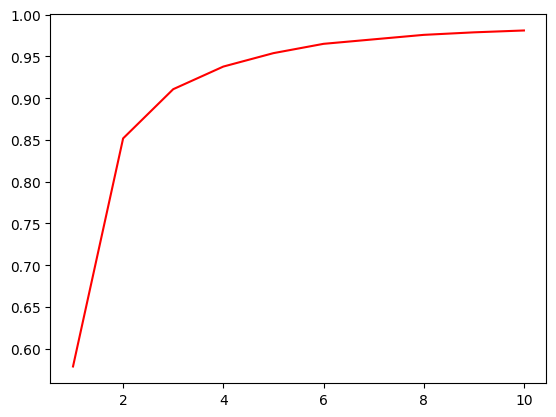

In [63]:
# Training accuracy
plt.plot(epochs, training_history.history["accuracy"], color="red", label="Training Accuracy")

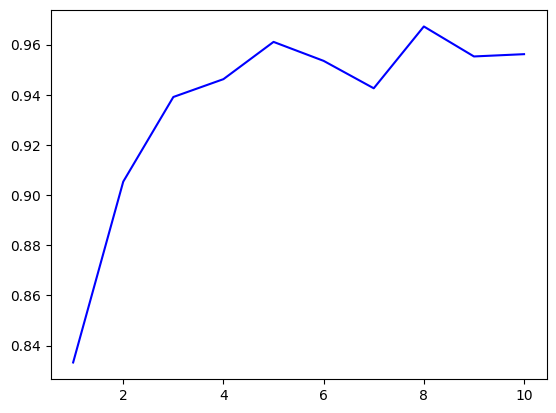

In [66]:
# Validation accuracy
plt.plot(epochs, training_history.history["val_accuracy"], color="blue", label="Validation Accuracy")

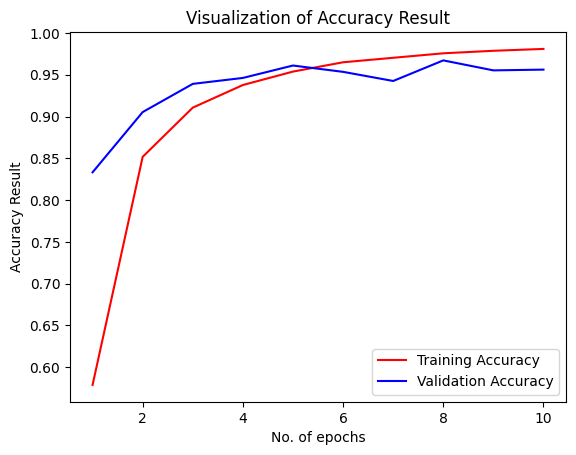

In [68]:
plt.plot(epochs, training_history.history["accuracy"], color="red", label="Training Accuracy")
plt.plot(epochs, training_history.history["val_accuracy"], color="blue", label="Validation Accuracy")
plt.xlabel("No. of epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()